# 3. Инференс и итоговые метрики

Запуск сохранённой модели как у организаторов, устойчивость к плохим входам, итоговые метрики с бутстрэп-ДИ (2000 повторов по группам), возрастные подгруппы, калибровка, оценка баллов.

Метрики — только по OOF вложенной валидации: каждого испытуемого предсказывает модель, которая его не видела. Предсказания финальной модели на обучающих данных оптимистичны и показаны лишь для сравнения.

In [1]:
import shutil
import sys
import tempfile
import time
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

from model.model import load, predict, run
from src import config, dataset, evaluation, models, viz

warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
WEIGHTS = ROOT / "model" / "weights"
OOF_PATH = ROOT / "results" / "validation" / "protocol8" / "nested_oof.csv"

## 3.1 Запуск как у организаторов

`load` читает веса, `run` обходит папки испытуемых и пишет CSV `subject_id, ptsd_probability`. Для примера во временную папку копируется по одному испытуемому каждой страты.

In [2]:
model = load(WEIGHTS)
print(f"Модель: {model.metadata['protocol']}, {model.metadata['candidate']}, признаков {len(model.feature_names)}; "
      f"калибровка Платта a = {model.calibration[0]:.3f}, b = {model.calibration[1]:.3f}")

data = models.load_training_data(protocol=models.PROTOCOL_8)
stratum_of = dict(zip(data.subject_keys, data.stratum))
demo = [next(k for k in data.subject_keys if stratum_of[k] == s) for s in viz.STRATUM_ORDER]

tmp = Path(tempfile.mkdtemp())
input_dir = tmp / "input"
for key in demo:
    shutil.copytree(config.DATA_DIR / key, input_dir / Path(key).name)
start = time.perf_counter()
run(model, input_dir, tmp / "predictions.csv")
elapsed = time.perf_counter() - start
predictions = pd.read_csv(tmp / "predictions.csv", encoding="utf-8-sig")
print(f"{len(predictions)} испытуемых за {elapsed:.1f} с ({elapsed / len(predictions):.2f} с на испытуемого)")
predictions.assign(страта=[viz.STRATUM_LABELS[stratum_of[k]] for k in sorted(demo, key=lambda k: Path(k).name)])

Модель: protocol8, C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp, признаков 23; калибровка Платта a = 0.822, b = 0.236


7 испытуемых за 0.7 с (0.09 с на испытуемого)


,subject_id,ptsd_probability,страта
0,34PHG,0.713,ПТСР
1,A003_68,0.014,нормы 65+
2,ABXZ5,0.467,соматоформные
3,КС010_19,0.837,норма A
4,КС027_34,0.785,норма B
5,КС056_22,0.134,норма C
6,КС201_23,0.585,доп. нормы


Эти испытуемые были в обучении — здесь проверяется только механика запуска.

## 3.2 Плохие входы

Пустая папка, только покой, обрезанный EDF, кириллические имена файлов.

In [3]:
bad_dir = tmp / "bad_input"
source = config.DATA_DIR / demo[0]
(bad_dir / "empty").mkdir(parents=True)
(bad_dir / "rest_only").mkdir()
shutil.copy(source / "T-П.edf", bad_dir / "rest_only" / "T-П.edf")
(bad_dir / "truncated").mkdir()
(bad_dir / "truncated" / "T-П.edf").write_bytes((source / "T-П.edf").read_bytes()[:3000])
(bad_dir / "cyrillic_names").mkdir()
shutil.copy(source / "T-П.edf", bad_dir / "cyrillic_names" / "Т-П.edf")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    run(model, bad_dir, tmp / "bad_predictions.csv")
bad = pd.read_csv(tmp / "bad_predictions.csv", encoding="utf-8-sig")
print("Все вероятности конечны и в [0, 1]:", bool(bad["ptsd_probability"].between(0, 1).all()))
print("Предупреждений:", len(caught))
bad

Все вероятности конечны и в [0, 1]: True
Предупреждений: 0


,subject_id,ptsd_probability
0,cyrillic_names,0.713
1,empty,0.201
2,rest_only,0.713
3,truncated,0.201


«Только покой» и кириллические имена дают ту же P, что полный набор файлов (модель использует только покой). Пустая папка и повреждённый файл получают P для «всё неизвестно».

## 3.3 Одинаковые признаки при обучении и инференсе

Вероятности по пути `predict` и по обучающей таблице для всех 229 испытуемых:

In [4]:
start = time.perf_counter()
p_inference = np.array([predict(model, config.DATA_DIR / key) for key in data.subject_keys])
elapsed = time.perf_counter() - start
p_training = model.predict_proba(data.tables[model.metadata["feature_set"]])
print(f"Инференс 229 испытуемых: {elapsed:.0f} с; максимальное расхождение с обучающей таблицей: "
      f"{np.abs(p_inference - p_training).max():.1e}")

Инференс 229 испытуемых: 11 с; максимальное расхождение с обучающей таблицей: 3.3e-16


In [5]:
oof = pd.read_csv(OOF_PATH, index_col=0).loc[list(data.subject_keys)]
stratum, groups = oof["stratum"].to_numpy(), oof["split_group"].to_numpy()
ptsd = stratum == models.STRATUM_PTSD
young = np.isin(stratum, ["control_A", "control_B", "control_C", "control_B_supplement"])


def auc_vs(p: np.ndarray, negatives: np.ndarray) -> float:
    mask = ptsd | negatives
    return roc_auc_score(ptsd[mask], p[mask])


pd.DataFrame({
    "финальная модель на обучающих данных (оптимистично)": {
        "AUC ПТСР / нормы < 65": auc_vs(p_inference, young),
        "AUC ПТСР / нормы 65+ и соматоформные": auc_vs(p_inference, np.isin(stratum, ["control_ageing", "somatoform"])),
        "чувствительность при 0.5": np.mean(p_inference[ptsd] >= 0.5)},
    "вложенная валидация, OOF (оценка качества)": {
        "AUC ПТСР / нормы < 65": auc_vs(oof["p_raw"].to_numpy(), young),
        "AUC ПТСР / нормы 65+ и соматоформные": auc_vs(oof["p_raw"].to_numpy(), np.isin(stratum, ["control_ageing", "somatoform"])),
        "чувствительность при 0.5": np.mean(oof["p"].to_numpy()[ptsd] >= 0.5)},
})

,финальная модель на обучающих данных (оптимистично),"вложенная валидация, OOF (оценка качества)"
AUC ПТСР / нормы < 65,0.923,0.864
AUC ПТСР / нормы 65+ и соматоформные,0.894,0.816
чувствительность при 0.5,0.960,0.840


Разница столбцов — оптимизм оценки на обучающих данных.

## 3.4 Итоговые метрики

«Нормы < 65» — все нормы моложе 65 лет (пара «ПТСР/контроль» ТЗ); состав тестовой пары неизвестен, поэтому показан и вариант без формата C. Пороговые метрики — по сдаваемой вероятности при 0.5.

In [6]:
report = evaluation.summarize_protocol3(oof, groups)
p, p_raw = oof["p"].to_numpy(), oof["p_raw"].to_numpy()


def ci(entry: dict) -> str:
    return f"{entry['value']:.3f} [{entry['ci_low']:.3f}; {entry['ci_high']:.3f}]"


auc_rows = {"ПТСР / нормы < 65": "auc_ptsd_vs_controls_excl_ageing", "ПТСР / нормы A, B, доп. партия": "auc_ptsd_vs_controls_AB"}
auc_table = pd.DataFrame({
    col: {**{name: ci(report[col][key]) for name, key in auc_rows.items()},
          **{f"ПТСР / {viz.STRATUM_LABELS[s]}": f"{v:.3f}" for s, v in report[col]["auc_ptsd_vs_stratum"].items()}}
    for col in ("p_raw", "p")
}).rename(columns={"p_raw": "некалиброванная", "p": "калиброванная (сдаётся)"})
auc_table.rename_axis("ROC-AUC")

,некалиброванная,калиброванная (сдаётся)
ROC-AUC,,
ПТСР / нормы < 65,0.864 [0.796; 0.919],0.824 [0.753; 0.886]
"ПТСР / нормы A, B, доп. партия",0.765 [0.661; 0.862],0.697 [0.589; 0.803]
ПТСР / норма A,0.670,0.622
ПТСР / норма B,0.460,0.500
ПТСР / доп. нормы,0.828,0.744
ПТСР / норма C,1.000,1.000
ПТСР / нормы 65+,0.890,0.877
ПТСР / соматоформные,0.792,0.731


In [7]:
sens = evaluation.rate_with_ci(p[ptsd] >= 0.5, groups[ptsd])
spec_young = evaluation.rate_with_ci(p[young] < 0.5, groups[young])
threshold = {
    "чувствительность (ПТСР)": ci(sens),
    "специфичность: нормы < 65": ci(spec_young),
    "специфичность: нормы 65+": ci(report["p"]["specificity_ageing"]),
    "специфичность: соматоформные": ci(report["p"]["specificity_somatoform"]),
    "специфичность: 65+ и соматоформные вместе": ci(report["p"]["specificity_ageing_and_somatoform_pooled"]),
    "сбалансированная точность: ПТСР / нормы < 65": f"{0.5 * (sens['value'] + spec_young['value']):.3f}",
    "сбалансированная точность: ПТСР / все не-ПТСР": f"{report['p']['threshold_metrics']['balanced_accuracy_vs_all_non_ptsd']:.3f}",
    "Brier (все испытуемые)": f"{report['p']['brier_all_subjects']:.3f}",
}
pd.Series(threshold, name="порог 0.5, калиброванная вероятность").to_frame()

,"порог 0.5, калиброванная вероятность"
чувствительность (ПТСР),0.840 [0.692; 0.958]
специфичность: нормы < 65,0.720 [0.636; 0.804]
специфичность: нормы 65+,0.870 [0.739; 1.000]
специфичность: соматоформные,0.608 [0.500; 0.718]
специфичность: 65+ и соматоформные вместе,0.670 [0.573; 0.760]
сбалансированная точность: ПТСР / нормы < 65,0.780
сбалансированная точность: ПТСР / все не-ПТСР,0.768
Brier (все испытуемые),0.185


## 3.5 ROC-кривые

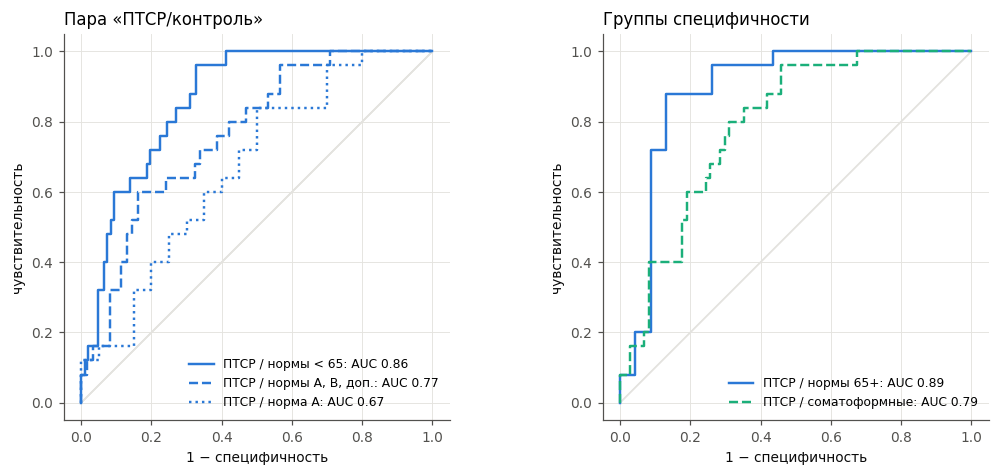

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
control = viz.COHORT_COLORS[config.GROUP_CONTROL]
panels = [
    [("нормы < 65", young, "-"), ("нормы A, B, доп.", np.isin(stratum, ["control_A", "control_B", "control_B_supplement"]), "--"),
     ("норма A", stratum == "control_A", ":")],
    [("нормы 65+", stratum == "control_ageing", "-"), ("соматоформные", stratum == "somatoform", "--")],
]
for ax, panel in zip(axes, panels):
    for label, negatives, ls in panel:
        mask = ptsd | negatives
        color = viz.COHORT_COLORS[config.GROUP_SOMATOFORM] if label == "соматоформные" else control
        viz.plot_roc(ax, ptsd[mask].astype(int), p_raw[mask], f"ПТСР / {label}", color, ls)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_title("Пара «ПТСР/контроль»", loc="left")
axes[1].set_title("Группы специфичности", loc="left")
plt.tight_layout()
plt.show()

## 3.6 Вероятность по стратам

Точка — испытуемый, линия — медиана, пунктир — порог 0.5. Таблица — доля P ≥ 0.5 с 95% ДИ (для ПТСР это чувствительность).

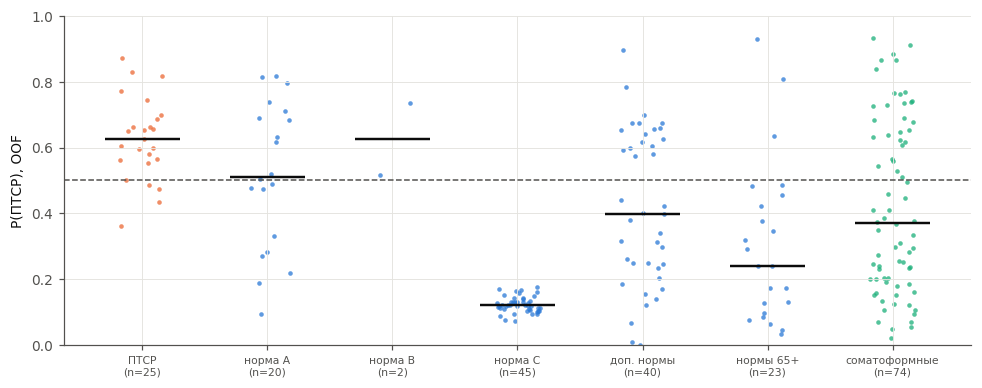

,n,доля P ≥ 0.5,2.5%,97.5%,медиана P
ПТСР,25.0,0.840,0.692,0.958,0.626
норма A,20.0,0.550,0.350,0.750,0.512
норма B,2.0,1.000,1.000,1.000,0.627
норма C,45.0,0.000,0.000,0.000,0.121
доп. нормы,40.0,0.425,0.275,0.575,0.399
нормы 65+,23.0,0.130,0.000,0.261,0.240
соматоформные,74.0,0.392,0.282,0.500,0.370


In [9]:
fig, ax = plt.subplots(figsize=(9, 3.6))
viz.plot_by_stratum(ax, p, stratum)
ax.axhline(0.5, color=viz.TEXT_MUTED, ls="--", lw=1)
ax.set_ylabel("P(ПТСР), OOF")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

rows = {}
for s in viz.STRATUM_ORDER:
    m = stratum == s
    r = evaluation.rate_with_ci(p[m] >= 0.5, groups[m])
    rows[viz.STRATUM_LABELS[s]] = {"n": int(m.sum()), "доля P ≥ 0.5": r["value"], "2.5%": r["ci_low"], "97.5%": r["ci_high"],
                                   "медиана P": float(np.median(p[m]))}
pd.DataFrame(rows).T

## 3.7 Возрастные подгруппы

Возраст известен только у норм. В каждой подгруппе AUC — все ПТСР против норм этого возраста. Возраст здесь переплетён с партией (состав справа).

In [10]:
subjects = dataset.scan_dataset(config.DATA_DIR)[2]
age = subjects.loc[list(data.subject_keys), "age"].to_numpy(dtype=float)
age = np.where(np.char.startswith(stratum.astype(str), "control_"), age, np.nan)
by_age = evaluation.metrics_by_age(p, age, ptsd).join(
    evaluation.metrics_by_age(p_raw, age, ptsd)[["auc_ptsd_vs_band"]], rsuffix="_raw")
by_age = by_age.drop(columns="auc_ptsd_vs_band").rename(columns={
    "n": "норм", "median_p": "медиана P", "specificity": "специфичность при 0.5", "auc_ptsd_vs_band_raw": "AUC ПТСР / подгруппа"})
bands = pd.cut(age, [0, 30, 46, 65, np.inf], right=False, labels=list(by_age.index))
composition = pd.crosstab(bands, pd.Series(stratum).map(viz.STRATUM_LABELS).to_numpy())
by_age.join(composition)

,норм,медиана P,специфичность при 0.5,AUC ПТСР / подгруппа,доп. нормы,норма A,норма B,норма C,нормы 65+
17-29,65,0.269,0.631,0.828,34,15,0,16,0
30-45,28,0.153,0.821,0.903,6,3,2,17,0
46-64,14,0.115,0.929,0.954,0,2,0,12,0
65+,23,0.240,0.870,0.890,0,0,0,0,23


## 3.8 Калибровка

Калибровка с равными весами классов: P читается как вероятность при равных шансах, поэтому точки лежат ниже диагонали — это задумано. Пересчёт на распространённость π: `odds_π = odds · π/(1 − π)`.

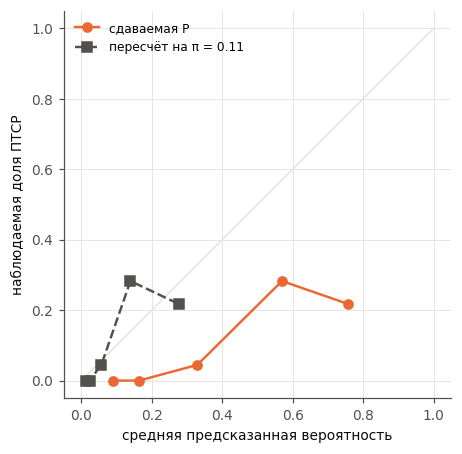

,испытуемых,средняя P,доля ПТСР,пересчёт на долю ПТСР в данных
0,46,0.090,0.000,0.012
1,46,0.164,0.000,0.023
2,45,0.329,0.044,0.057
3,46,0.570,0.283,0.140
4,46,0.757,0.217,0.277


In [11]:
rel = pd.DataFrame(report["p"]["reliability"])
prevalence = ptsd.mean()
balanced = rel["mean_p"] / (1 - rel["mean_p"]) * prevalence / (1 - prevalence)
rel["пересчёт на долю ПТСР в данных"] = balanced / (1 + balanced)
fig, ax = plt.subplots(figsize=(4.4, 4.2))
ax.plot([0, 1], [0, 1], color=viz.GRID, lw=1)
ax.plot(rel["mean_p"], rel["observed"], "o-", color=viz.COHORT_COLORS[config.GROUP_PTSD], label="сдаваемая P")
ax.plot(rel["пересчёт на долю ПТСР в данных"], rel["observed"], "s--", color=viz.TEXT_MUTED, label=f"пересчёт на π = {prevalence:.2f}")
ax.set_xlabel("средняя предсказанная вероятность")
ax.set_ylabel("наблюдаемая доля ПТСР")
ax.set_aspect("equal")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
rel.rename(columns={"n": "испытуемых", "mean_p": "средняя P", "observed": "доля ПТСР"})

## 3.9 Оценка баллов по формуле ТЗ

`30·max(0, (AUC − 0.5)/0.5)` на паре «ПТСР/контроль» и `20·(1 − FPR)` на 65+ и соматоформных при 0.5. Границы — по 95% ДИ; это оценка по данным разработки, а не прогноз теста.

In [12]:
def auc_points(a: float) -> float:
    return 30.0 * max(0.0, (a - 0.5) / 0.5)


spec_pooled = report["p"]["specificity_ageing_and_somatoform_pooled"]
score = {}
for name, key in auc_rows.items():
    a = report["p_raw"][key]
    score[f"AUC-часть, {name}"] = [auc_points(a["value"]), auc_points(a["ci_low"]), auc_points(a["ci_high"])]
score["специфичность-часть, 65+ и соматоформные"] = [20 * spec_pooled["value"], 20 * spec_pooled["ci_low"], 20 * spec_pooled["ci_high"]]
pd.DataFrame(score, index=["оценка", "нижняя граница", "верхняя граница"]).T.round(1)

,оценка,нижняя граница,верхняя граница
"AUC-часть, ПТСР / нормы < 65",21.8,17.8,25.1
"AUC-часть, ПТСР / нормы A, B, доп. партия",15.9,9.6,21.7
"специфичность-часть, 65+ и соматоформные",13.4,11.5,15.2


## 3.10 Выводы

1. Модель запускается интерфейсом ТЗ без переобучения (~0.1 с на испытуемого) и не падает на плохих входах; признаки при инференсе совпадают с обучающими.
2. AUC ПТСР против норм моложе 65 — 0.864 [0.796; 0.919], против норм A/B и доп. партии — 0.765 [0.661; 0.862], против нормы A — 0.67.
3. При 0.5: чувствительность 0.84, специфичность 65+ 0.87, соматоформных 0.61; сбалансированная точность 0.78.
4. Больше всего ложноположительных у нормы A (11 из 20) и доп. партии (17 из 40).
5. Оценка баллов: AUC-часть 16–22 из 30, специфичность 13.4 из 20. Порог стоит в точке равных ошибок: калибровка по составу обучения дала бы почти 20 за специфичность, но нулевую чувствительность.

In [13]:
shutil.rmtree(tmp, ignore_errors=True)